# Notebook 05: Paper Reported Models Transcription & Architectural Audit

## Research Reference
**"An approach for accurate identification and monitoring of species in mangrove forests based on multi-source spectral data and deep learning"**  
*Monterrubio-Martínez, Trujillo-Acatitla, Tuxpan-Vargas, Moreno-Casasola*  
*Ecological Informatics*, Volume 85, 2025, Article 102961. DOI: [10.1016/j.ecoinf.2024.102961](https://doi.org/10.1016/j.ecoinf.2024.102961)

## Scientific Classification
**`PAPER REPORTED RESULTS`**  

> ### [!IMPORTANT]
> **SCIENTIFIC METHODOLOGY MANDATE:**
> - The paper evaluated two primary classification tasks:
>   1. **Binary Task (60,000 pixels)**: Mangrove vs Non-mangrove (30k mangrove + 30k non-mangrove).
>   2. **Multiclass Task (40,000 pixels)**: 4 classes (10k each of *R. mangle*, *A. germinans*, *L. racemosa*, and non-mangrove).
> - The non-mangrove class and the subsampled 60k/40k splits were **not included in the authors' public repository**.
> - Under strict research reproduction ethics, we **do not fabricate substitute non-mangrove data** and do **not claim to have reproduced these numerical values**.
> - Instead, this notebook provides a comprehensive transcription, architectural inventory, and comparative analysis of the published results transcribed directly from the paper text (Section 3.2, 3.3) and publication figures (Fig. 5, Fig. 6, Fig. 9).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import RESULTS_MODELS_DIR, RESULTS_FIGURES_DIR

print("Environment initialized successfully.")

Environment initialized successfully.


## 1. Transcription of Published Binary MLP Results (60,000 Pixels)

Transcribed directly from Section 3.2 and Figure 5 of Monterrubio-Martínez et al. (2025):

In [2]:
binary_reported_data = [
    {"Model": "Logistic Regression", "Layers": 0, "Neurons": 0, "Train_Acc": 0.9916, "Test_Acc": 0.9910, "Notes": "Baseline model (lowest binary score)"},
    {"Model": "MLP 1 Layer (300N)", "Layers": 1, "Neurons": 300, "Train_Acc": 0.9995, "Test_Acc": 0.9988, "Notes": "Top score for 1 hidden layer"},
    {"Model": "MLP 2 Layers (100N)", "Layers": 2, "Neurons": 100, "Train_Acc": 0.9994, "Test_Acc": 0.9987, "Notes": "Top score for 2 hidden layers"},
    {"Model": "MLP 3 Layers (50N)", "Layers": 3, "Neurons": 50, "Train_Acc": 0.9996, "Test_Acc": 0.9987, "Notes": "Most optimal scores overall (Section 3.2)"},
    {"Model": "MLP 4 Layers (150N)", "Layers": 4, "Neurons": 150, "Train_Acc": 0.9993, "Test_Acc": 0.9986, "Notes": "Shared top score for 4 layers"},
    {"Model": "MLP 4 Layers (300N)", "Layers": 4, "Neurons": 300, "Train_Acc": 0.9993, "Test_Acc": 0.9986, "Notes": "Most reliable spatial model (Section 3.3, Fig 7)"},
    {"Model": "MLP 5 Layers (50N)", "Layers": 5, "Neurons": 50, "Train_Acc": 0.9995, "Test_Acc": 0.9988, "Notes": "Shared top score for 5 layers"},
    {"Model": "MLP 5 Layers (300N)", "Layers": 5, "Neurons": 300, "Train_Acc": 0.9995, "Test_Acc": 0.9988, "Notes": "Shared top score for 5 layers"},
]

df_binary_reported = pd.DataFrame(binary_reported_data)
display(df_binary_reported)

RESULTS_MODELS_DIR.mkdir(parents=True, exist_ok=True)
df_binary_reported.to_csv(RESULTS_MODELS_DIR / "paper_reported_binary.csv", index=False)
print("Saved paper reported binary results to results/models/paper_reported_binary.csv")

,Model,Layers,Neurons,Train_Acc,Test_Acc,Notes
0,Logistic Regression,0,0,0.9916,0.9910,Baseline model (lowest binary score)
1,MLP 1 Layer (300N),1,300,0.9995,0.9988,Top score for 1 hidden layer
2,MLP 2 Layers (100N),2,100,0.9994,0.9987,Top score for 2 hidden layers
3,MLP 3 Layers (50N),3,50,0.9996,0.9987,Most optimal scores overall (Section 3.2)
4,MLP 4 Layers (150N),4,150,0.9993,0.9986,Shared top score for 4 layers
5,MLP 4 Layers (300N),4,300,0.9993,0.9986,"Most reliable spatial model (Section 3.3, Fig 7)"
6,MLP 5 Layers (50N),5,50,0.9995,0.9988,Shared top score for 5 layers
7,MLP 5 Layers (300N),5,300,0.9995,0.9988,Shared top score for 5 layers


Saved paper reported binary results to results/models/paper_reported_binary.csv


## 2. Transcription of Published Multiclass MLP Results (40,000 Pixels, 4 Classes)

Transcribed directly from Section 3.2, Section 3.3, Figure 6, and Figure 9:

In [3]:
multiclass_reported_data = [
    {"Model": "Logistic Regression", "Layers": 0, "Neurons": 0, "Train_Acc": 0.7670, "Test_Acc": 0.7684, "Notes": "Baseline model (lowest multiclass score)"},
    {"Model": "MLP 1 Layer (500N)", "Layers": 1, "Neurons": 500, "Train_Acc": 0.9110, "Test_Acc": 0.9065, "Notes": "Top score for 1 hidden layer"},
    {"Model": "MLP 2 Layers (300N)", "Layers": 2, "Neurons": 300, "Train_Acc": 0.9575, "Test_Acc": 0.9436, "Notes": "Top score for 2 hidden layers"},
    {"Model": "MLP 3 Layers (500N)", "Layers": 3, "Neurons": 500, "Train_Acc": 0.9863, "Test_Acc": 0.9654, "Notes": "Highest test accuracy in paper"},
    {"Model": "MLP 4 Layers (100N)", "Layers": 4, "Neurons": 100, "Train_Acc": 0.9662, "Test_Acc": 0.9528, "Notes": "Reported in Section 3.3 / Fig 9B"},
    {"Model": "MLP 4 Layers (150N)", "Layers": 4, "Neurons": 150, "Train_Acc": 0.9775, "Test_Acc": 0.9607, "Notes": "Reported in Section 3.3 / Fig 9C"},
    {"Model": "MLP 4 Layers (300N)", "Layers": 4, "Neurons": 300, "Train_Acc": 0.9795, "Test_Acc": 0.9602, "Notes": "Reported in Section 3.2 & Fig 8F"},
    {"Model": "MLP 5 Layers (50N)", "Layers": 5, "Neurons": 50, "Train_Acc": 0.9550, "Test_Acc": 0.9454, "Notes": "Most reliable model for spatial distribution (Fig 9E, 10E)"},
    {"Model": "MLP 5 Layers (150N)", "Layers": 5, "Neurons": 150, "Train_Acc": 0.9810, "Test_Acc": 0.9632, "Notes": "Reported in Section 3.3 / Fig 9E"},
    {"Model": "MLP 5 Layers (300N)", "Layers": 5, "Neurons": 300, "Train_Acc": 0.9873, "Test_Acc": 0.9684, "Notes": "Peak multiclass test accuracy"},
]

df_multiclass_reported = pd.DataFrame(multiclass_reported_data)
display(df_multiclass_reported)

df_multiclass_reported.to_csv(RESULTS_MODELS_DIR / "paper_reported_multiclass.csv", index=False)
print("Saved paper reported multiclass results to results/models/paper_reported_multiclass.csv")

,Model,Layers,Neurons,Train_Acc,Test_Acc,Notes
0,Logistic Regression,0,0,0.7670,0.7684,Baseline model (lowest multiclass score)
1,MLP 1 Layer (500N),1,500,0.9110,0.9065,Top score for 1 hidden layer
2,MLP 2 Layers (300N),2,300,0.9575,0.9436,Top score for 2 hidden layers
3,MLP 3 Layers (500N),3,500,0.9863,0.9654,Highest test accuracy in paper
4,MLP 4 Layers (100N),4,100,0.9662,0.9528,Reported in Section 3.3 / Fig 9B
5,MLP 4 Layers (150N),4,150,0.9775,0.9607,Reported in Section 3.3 / Fig 9C
6,MLP 4 Layers (300N),4,300,0.9795,0.9602,Reported in Section 3.2 & Fig 8F
7,MLP 5 Layers (50N),5,50,0.9550,0.9454,Most reliable model for spatial distribution (...
8,MLP 5 Layers (150N),5,150,0.9810,0.9632,Reported in Section 3.3 / Fig 9E
9,MLP 5 Layers (300N),5,300,0.9873,0.9684,Peak multiclass test accuracy


Saved paper reported multiclass results to results/models/paper_reported_multiclass.csv


## 3. Visualization of Published Accuracies

We visualize the published training and testing accuracies across layers and neuron sizes.

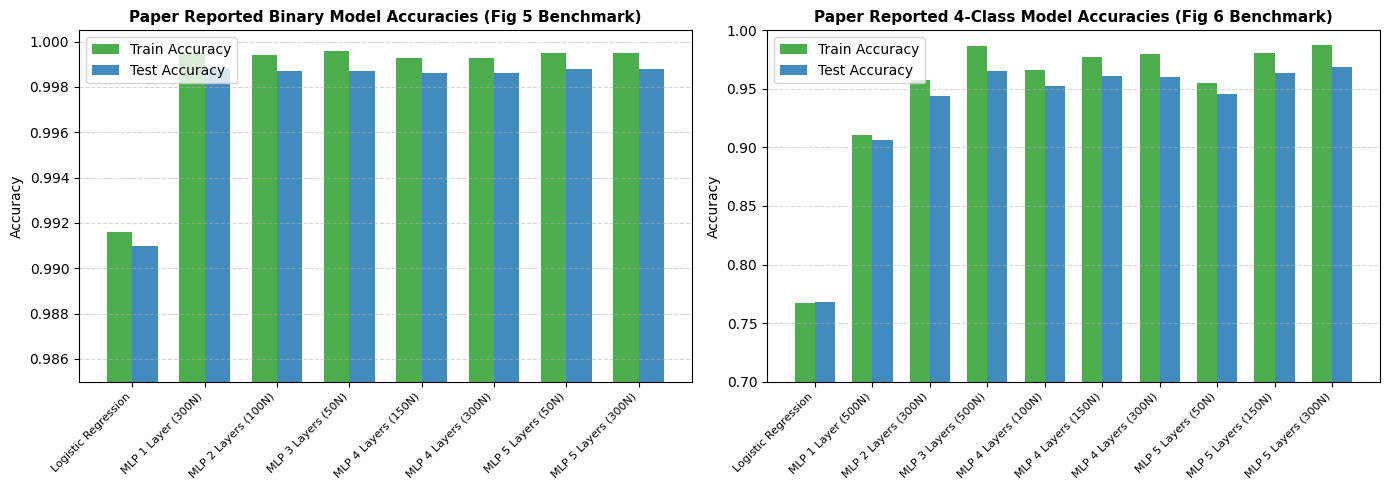

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Binary Plot
x = np.arange(len(df_binary_reported))
width = 0.35
ax1.bar(x - width/2, df_binary_reported["Train_Acc"], width, label="Train Accuracy", color="#2ca02c", alpha=0.85)
ax1.bar(x + width/2, df_binary_reported["Test_Acc"], width, label="Test Accuracy", color="#1f77b4", alpha=0.85)
ax1.set_ylabel("Accuracy")
ax1.set_title("Paper Reported Binary Model Accuracies (Fig 5 Benchmark)", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(df_binary_reported["Model"], rotation=45, ha="right", fontsize=8)
ax1.set_ylim(0.985, 1.0005)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend()

# Multiclass Plot
x2 = np.arange(len(df_multiclass_reported))
ax2.bar(x2 - width/2, df_multiclass_reported["Train_Acc"], width, label="Train Accuracy", color="#2ca02c", alpha=0.85)
ax2.bar(x2 + width/2, df_multiclass_reported["Test_Acc"], width, label="Test Accuracy", color="#1f77b4", alpha=0.85)
ax2.set_ylabel("Accuracy")
ax2.set_title("Paper Reported 4-Class Model Accuracies (Fig 6 Benchmark)", fontsize=11, fontweight="bold")
ax2.set_xticks(x2)
ax2.set_xticklabels(df_multiclass_reported["Model"], rotation=45, ha="right", fontsize=8)
ax2.set_ylim(0.70, 1.0)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_FIGURES_DIR / "paper_reported_accuracies_summary.png", dpi=300)
plt.show()

## 4. Architecture Inventory & Status Audit

We formalize the architecture inventory described by the paper into distinct status categories:

In [5]:
inventory = [
    {"Scope": "Explored in Paper", "Description": "1 to 5 hidden layers x 8 neuron sizes (5 to 500)", "Count": "40 MLPs + 1 Logistic = 41 configurations"},
    {"Scope": "Explicitly Reported in Paper Text/Figures (Binary)", "Description": "Logistic, 1L-300N, 2L-100N, 3L-50N, 4L-150N/300N, 5L-50N/300N", "Count": "8 configurations with numerical scores"},
    {"Scope": "Explicitly Reported in Paper Text/Figures (Multiclass)", "Description": "Logistic, 1L-500N, 2L-300N, 3L-500N, 4L-100N/150N/300N, 5L-50N/150N/300N", "Count": "10 configurations with numerical scores"},
    {"Scope": "Reproducible from Released Data", "Description": "ANOVA & Tukey on 3 species across 10 bands; 3-species Monospecific MLP", "Count": "One-way ANOVA (10 bands) + Tukey (30 pairs) + 41 3-species models"},
    {"Scope": "Data-Limited (Unreleased by Authors)", "Description": "Original 60k binary & 40k 4-class subsets (Non-mangrove missing); Full scene GeoTIFFs", "Count": "Unavailable in public repository"},
]

df_inventory = pd.DataFrame(inventory)
display(df_inventory)
df_inventory.to_csv(RESULTS_MODELS_DIR / "architecture_inventory.csv", index=False)

,Scope,Description,Count
0,Explored in Paper,1 to 5 hidden layers x 8 neuron sizes (5 to 500),40 MLPs + 1 Logistic = 41 configurations
1,Explicitly Reported in Paper Text/Figures (Bin...,"Logistic, 1L-300N, 2L-100N, 3L-50N, 4L-150N/30...",8 configurations with numerical scores
2,Explicitly Reported in Paper Text/Figures (Mul...,"Logistic, 1L-500N, 2L-300N, 3L-500N, 4L-100N/1...",10 configurations with numerical scores
3,Reproducible from Released Data,ANOVA & Tukey on 3 species across 10 bands; 3-...,One-way ANOVA (10 bands) + Tukey (30 pairs) + ...
4,Data-Limited (Unreleased by Authors),Original 60k binary & 40k 4-class subsets (Non...,Unavailable in public repository
